In [8]:
import numpy as np
import pandas as pd
import multiprocessing as mp
from inspect import signature
from matplotlib import pyplot as plt
from dacbench.logger import Logger, log2dataframe, load_logs
import seaborn as sns
import glob
from plotting import _plot_performance_over_time, plot_performance_over_time, plot_final_performance_comparison, plot_improvement_probability, plot_configuration_footprint, plot_hp_importance, plot_deepcave
#from plotting import plot_performance_over_time, plot_final_performance_comparison, plot_improvement_probability, plot_configuration_footprint, plot_hp_importance, plot_deepcave

In [9]:
import json
import glob
import pandas as pd
from typing import List
import seaborn as sns

def extract_metric_all_seeds(trainer_state_paths: List[str],
                             seeds: List[int],
                             metric_key: str,
                             method: str,
                             max_step: int = None) -> pd.DataFrame:
    """
    Given multiple trainer_state.json file paths (one per seed), extract a chosen metric
    (e.g., 'train_perplexity' or 'eval_perplexity') from each file and combine them into
    a single DataFrame with columns: ['step', 'seed', 'value', 'method'].
    
    :param trainer_state_paths: List of paths to trainer_state.json files.
    :param seeds: List of integer seeds corresponding to each file path.
    :param metric_key: The key for the metric to extract (e.g., 'train_perplexity').
    :param method: The method/optimizer name (e.g., 'COCOB', 'DAdaptAdam', etc.).
    :param max_step: Optional maximum step value. Only log entries with 'step' <= max_step will be kept.
    :return: A pandas DataFrame with columns ['step', 'seed', 'value', 'method'].
    """
    if len(trainer_state_paths) != len(seeds):
        raise ValueError("The number of trainer_state paths must match the number of seeds.")

    df_list = []
    for path, seed in zip(trainer_state_paths, seeds):
        with open(path, "r") as f:
            trainer_state = json.load(f)

        data_for_this_seed = []
        for log_entry in trainer_state.get("log_history", []):
            # Only include entries that have both the metric and a 'step'
            if metric_key in log_entry and "step" in log_entry:
                # If max_step is provided, skip entries beyond that step
                if max_step is not None and log_entry["step"] > max_step:
                    continue
                data_for_this_seed.append({
                    "step": log_entry["step"],
                    "seed": seed,
                    "value": log_entry[metric_key],
                    "method": method
                })

        if data_for_this_seed:
            df_list.append(pd.DataFrame(data_for_this_seed))

    if df_list:
        return pd.concat(df_list, ignore_index=True)
    else:
        # Return an empty DataFrame with the expected columns if no data is found.
        return pd.DataFrame(columns=["step", "seed", "value", "method"])

def extract_metric_from_parent_dir(parent_dir: str,
                                   metric_key: str,
                                   method: str,
                                   max_step: int = None) -> pd.DataFrame:
    """
    Searches for all trainer_state.json files within the subdirectories of the given parent directory,
    using a glob pattern that matches the structure:
    
        parent_dir/*/results/*/trainer_state.json
    
    Seeds are automatically assigned based on the sorted order of the files.
    
    :param parent_dir: The parent directory for the method (e.g. "./COCOB_roberta_bookwiki")
    :param metric_key: The metric key to extract (e.g., "train_perplexity" or "eval_perplexity")
    :param method: The method/optimizer name (e.g., "COCOB", "DAdaptAdam", etc.)
    :param max_step: Optional maximum step value. Only log entries with 'step' <= max_step will be kept.
    :return: A pandas DataFrame with columns ['step', 'seed', 'value', 'method'].
    """
    # Create the glob pattern to find trainer_state.json files
    pattern = f"{parent_dir}/*/results/*/trainer_state.json"
    trainer_state_paths = sorted(glob.glob(pattern))
    
    # Automatically assign seed values based on the sorted order
    seeds = list(range(1, len(trainer_state_paths) + 1))
    
    return extract_metric_all_seeds(trainer_state_paths, seeds, metric_key, method, max_step=max_step)

def downsample_data(df, bin_size=50):
    """
    Downsamples the DataFrame by binning steps.
    
    :param df: Input DataFrame with a 'step' column.
    :param bin_size: The bin size to aggregate over.
    :return: Downsampled DataFrame with binned steps.
    """
    # Create a new column for the bin index based on the step
    df['step'] = (df['step'] // bin_size) * bin_size
    # Group by method, seed, and binned step, then compute the mean value
    grouped = df.groupby(['method', 'seed', 'step'])['value'].mean().reset_index()
    return grouped

# Example of setting up Seaborn plotting options:
sns.set(rc={"figure.dpi":300, 'savefig.dpi':300})
sns.set_style('whitegrid')
palette = sns.color_palette("colorblind")
palette = sns.color_palette([palette[0], palette[2], palette[1], palette[3], palette[4], palette[5]])
sns.set_palette(palette)

          method  seed   step         value
0     Adam Fixed     1      0  29994.999162
1     Adam Fixed     1    100   8790.373594
2     Adam Fixed     1    200   2937.035546
3     Adam Fixed     1    300   1503.102111
4     Adam Fixed     1    400   1191.865066
...          ...   ...    ...           ...
1381     Prodigy     1  22600   1503.076931
1382     Prodigy     1  22700   1527.507976
1383     Prodigy     1  22800   1512.207485
1384     Prodigy     1  22900   1515.157913
1385     Prodigy     1  23000   1554.796753

[1386 rows x 4 columns]


/home/micha/Studium/BA_new/BA-Parameter-Free-DAC/ba_parameter_free_dac/plotting/plotting.py:207: UserWarning: The palette list has more values (10) than needed (6), which may not be intended.
  ax = sns.lineplot(data=data, x=x, y=y, ax=ax, marker=marker, hue=hue, errorbar=errorbar, estimator=aggregation,palette=sns.color_palette('colorblind', as_cmap = True))
/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/seabor

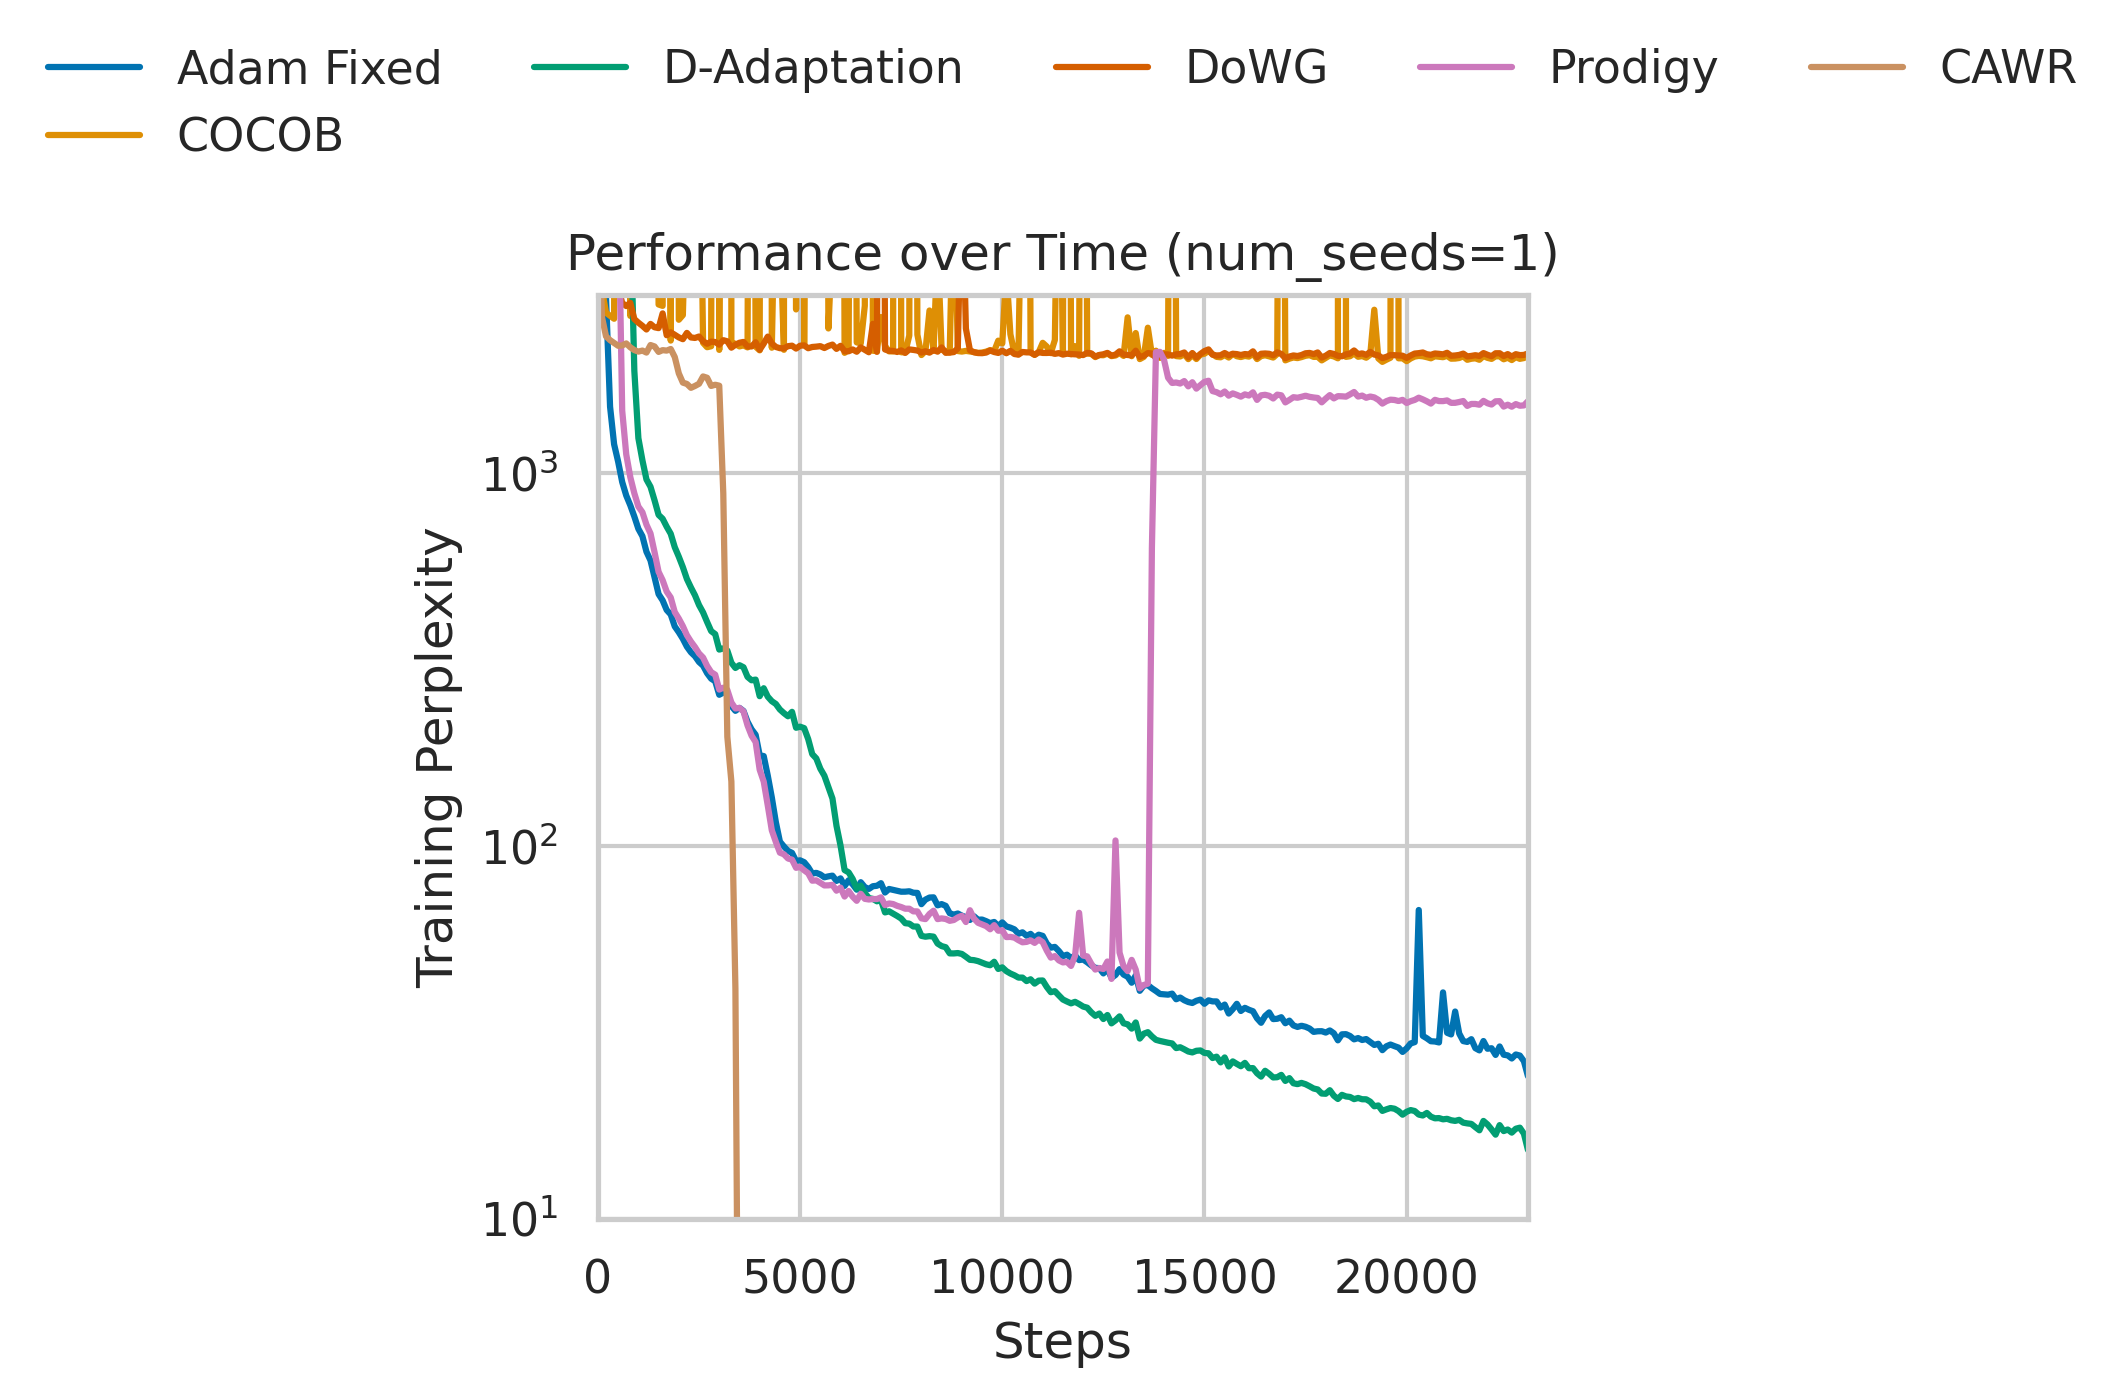

/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  func(*args, **kwargs)


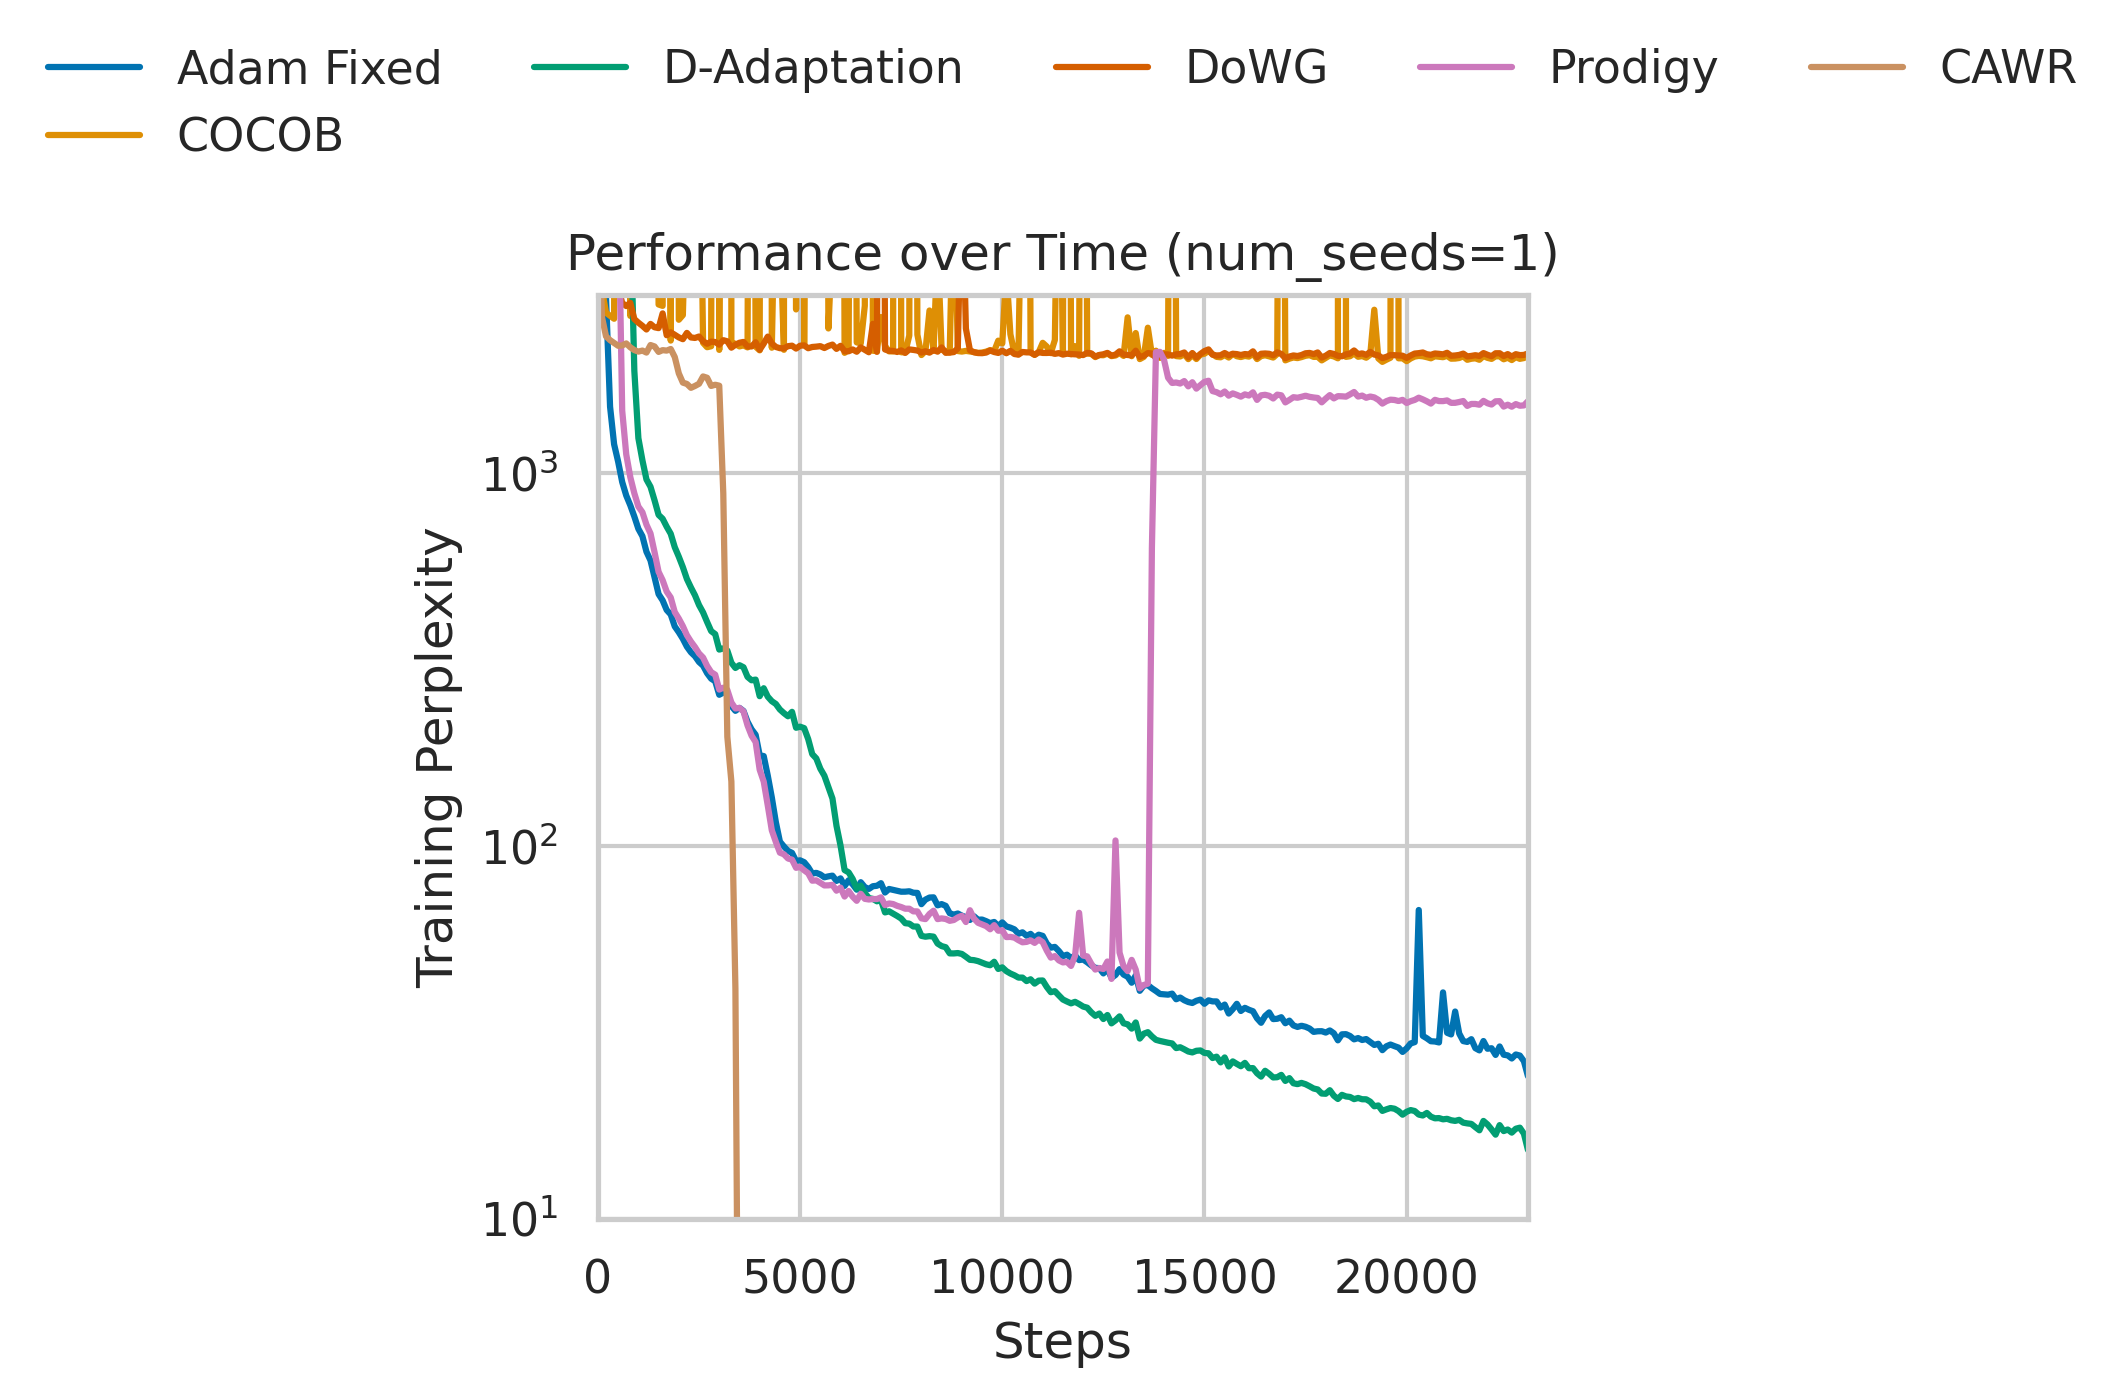

In [ ]:
max_steps=23000

adamfixed_tp = extract_metric_from_parent_dir(
    parent_dir="../results_cluster/results/Adam_fixed_roberta_bookwiki",
    metric_key="train_perplexity",
    method="Adam Fixed",
    max_step=max_steps
)

cawr_tp = extract_metric_from_parent_dir(
    parent_dir="../results_cluster/results/CAWR_roberta_bookwiki",
    metric_key="train_perplexity",
    method="CAWR",
    max_step=max_steps
)

cocob_tp = extract_metric_from_parent_dir(
    parent_dir="../results_cluster/results/COCOB_roberta_bookwiki",
    metric_key="train_perplexity",
    method="COCOB",
    max_step=max_steps
)

dadaptation_tp = extract_metric_from_parent_dir(
    parent_dir="../results_cluster/results/DAdaptAdam_roberta_bookwiki",
    metric_key="train_perplexity",
    method="D-Adaptation",
    max_step=max_steps
)

dowg_tp = extract_metric_from_parent_dir(
    parent_dir="../results_cluster/results/DoWG_roberta_bookwiki",
    metric_key="train_perplexity",
    method="DoWG",
    max_step=max_steps
)

prodigy_tp = extract_metric_from_parent_dir(
    parent_dir="../results_cluster/results/ProdigyAdam_roberta_bookwiki",
    metric_key="train_perplexity",
    method="Prodigy",
    max_step=max_steps
)

# Combine all training DataFrames:
df_train_all = pd.concat([cocob_tp, adamfixed_tp, dowg_tp, prodigy_tp, dadaptation_tp, cawr_tp], ignore_index=True)
df_train_all = downsample_data(df_train_all, bin_size=100)
print(cawr_tp)
desired_order = ["Adam Fixed", "COCOB", "D-Adaptation", "DoWG", "Prodigy", "CAWR"]
df_train_all["method"] = pd.Categorical(df_train_all["method"], categories=desired_order, ordered=True)
_plot_performance_over_time(
    df_train_all,
    x="step",
    y="value",
    hue="method",
    aggregation="mean",
    logx=False,
    logy=True,
    xlabel="Steps",
    ylabel="Training Perplexity",
    ylim=(10, 3000)  # Adjust as needed
)

       step  seed     value        method
0        50     1  3.347848         COCOB
1       100     1  8.972281         COCOB
2       150     1  3.005303         COCOB
3       200     1  2.503248         COCOB
4       250     1  2.749990         COCOB
...     ...   ...       ...           ...
4595  22800     2  2.727145  D-Adaptation
4596  22850     2  2.727145  D-Adaptation
4597  22900     2  2.727145  D-Adaptation
4598  22950     2  2.727145  D-Adaptation
4599  23000     2  2.727145  D-Adaptation

[4600 rows x 4 columns]


/home/micha/Studium/BA_new/BA-Parameter-Free-DAC/ba_parameter_free_dac/plotting/plotting.py:205: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  ax = sns.lineplot(data=data, x=x, y=y, ax=ax, marker=marker, hue=hue, errorbar=errorbar, estimator=aggregation,palette=sns.color_palette('colorblind', as_cmap = True))
/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/seabor

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


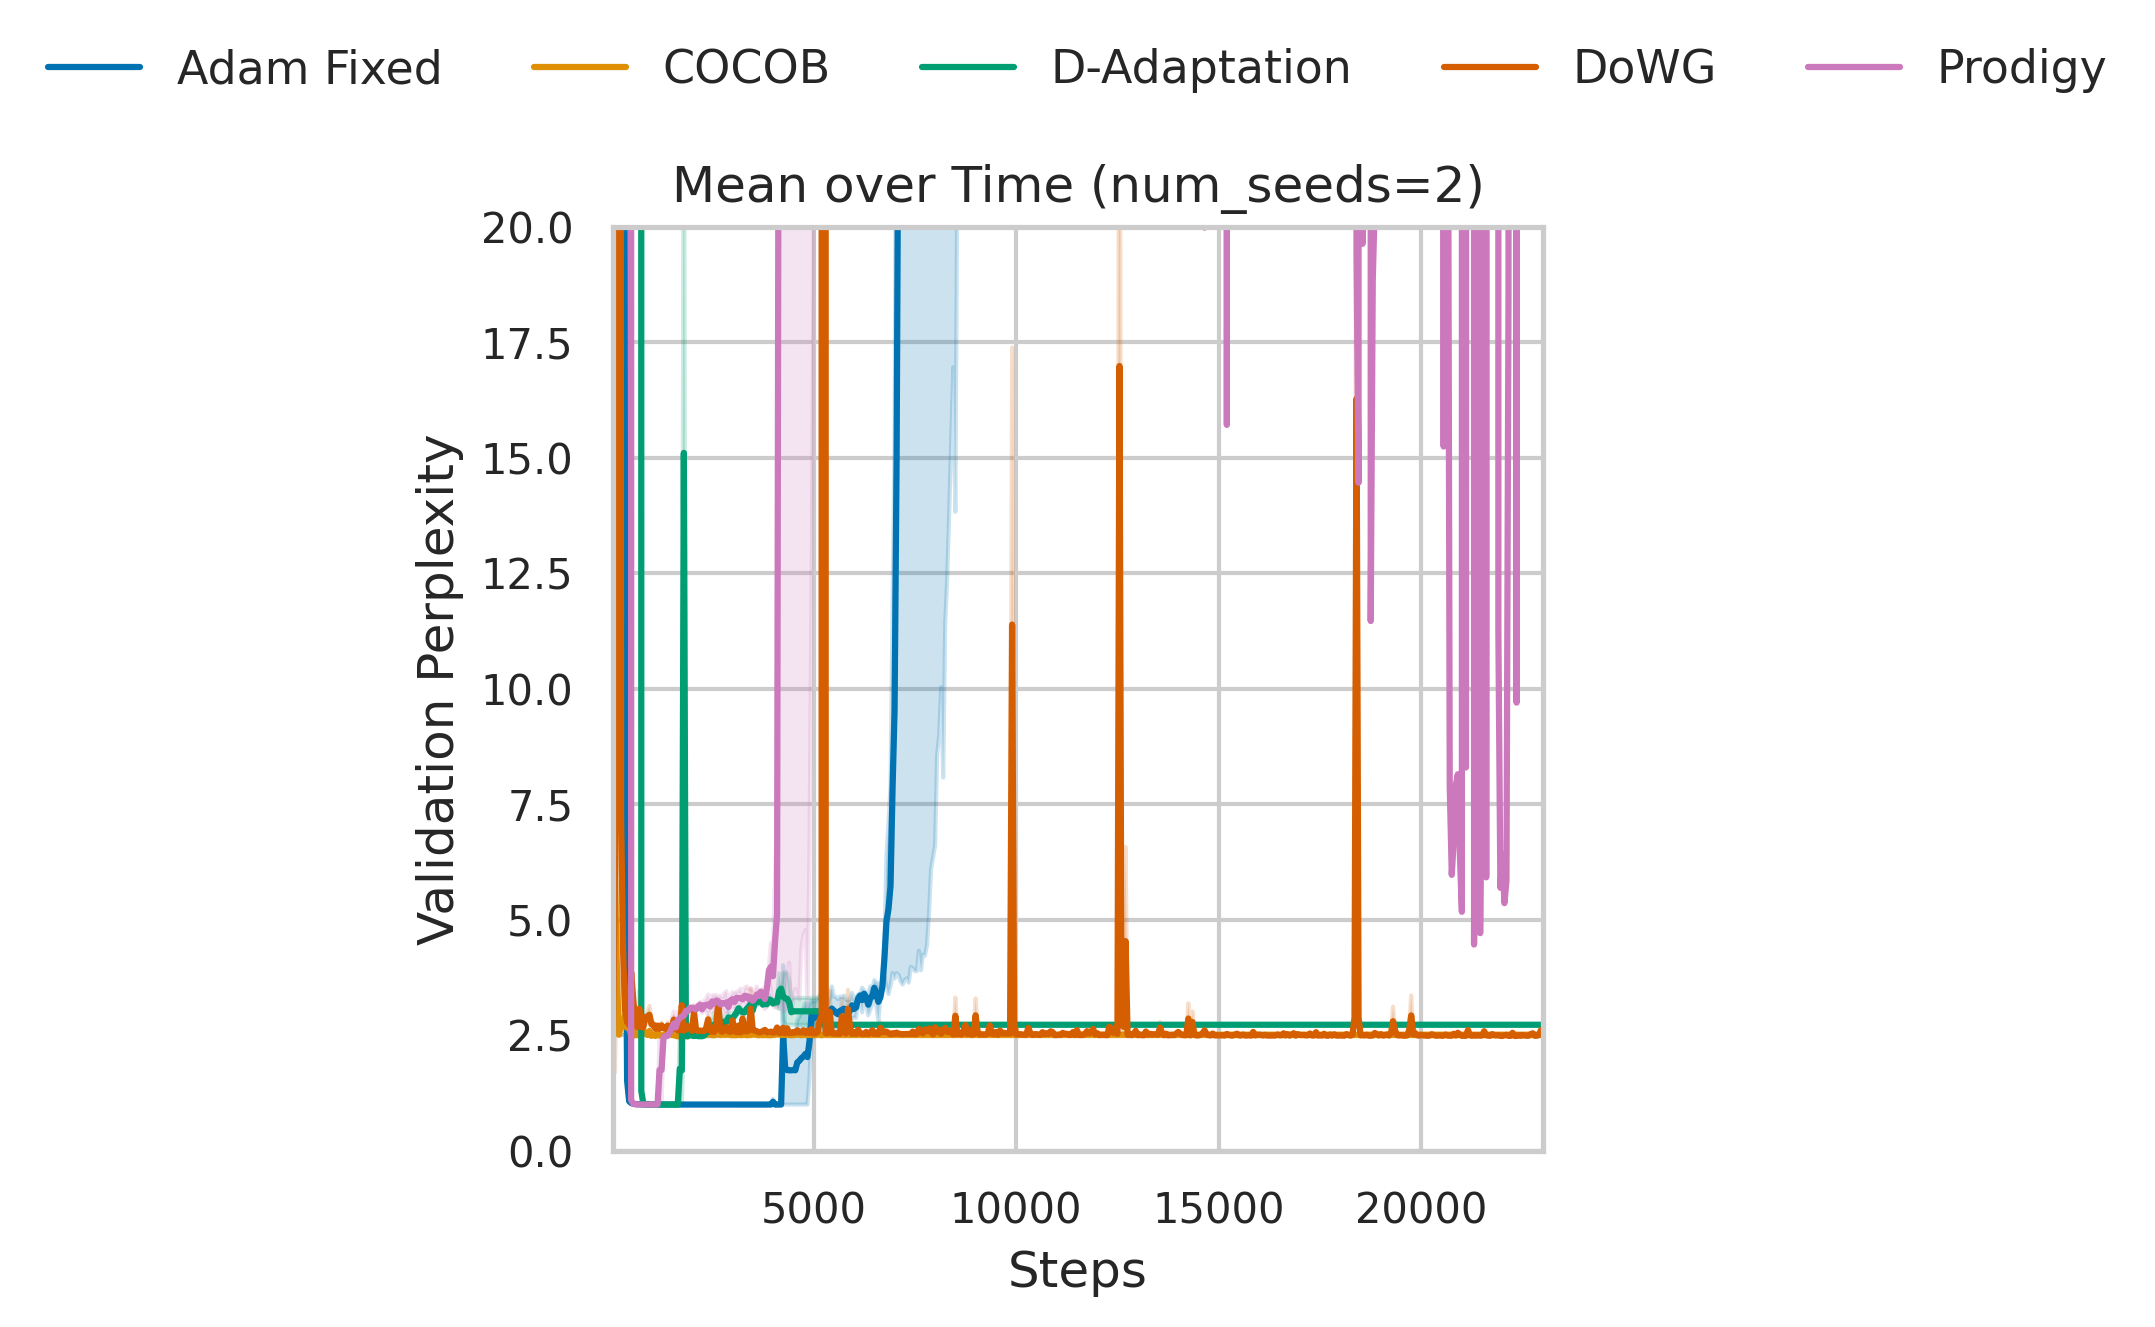

In [10]:
adamfixed_ep = extract_metric_from_parent_dir(
    parent_dir="../results_cluster/results/Adam_fixed_roberta_bookwiki",
    metric_key="eval_perplexity",
    method="Adam Fixed"
)

cocob_ep = extract_metric_from_parent_dir(
    parent_dir="../results_cluster/results/COCOB_roberta_bookwiki",
    metric_key="eval_perplexity",
    method="COCOB"
)

dadaptation_ep = extract_metric_from_parent_dir(
    parent_dir="../results_cluster/results/DAdaptAdam_roberta_bookwiki",
    metric_key="eval_perplexity",
    method="D-Adaptation"
)

dowg_ep = extract_metric_from_parent_dir(
    parent_dir="../results_cluster/results/DoWG_roberta_bookwiki",
    metric_key="eval_perplexity",
    method="DoWG"
)

prodigy_ep = extract_metric_from_parent_dir(
    parent_dir="../results_cluster/results/ProdigyAdam_roberta_bookwiki",
    metric_key="eval_perplexity",
    method="Prodigy"
)


# Combine all training DataFrames:
df_eval_all = pd.concat([cocob_ep, adamfixed_ep, dowg_ep, prodigy_ep, dadaptation_ep], ignore_index=True)
df_eval_all["method"] = pd.Categorical(df_eval_all["method"], categories=desired_order, ordered=True)
print(df_eval_all)
plot_performance_over_time(
    df_eval_all,
    x="step",
    y="value",
    hue="method",
    aggregation="mean",
    logx=False,
    xlabel="Steps",
    ylabel="Validation Perplexity",
    ylim=(0, 20)  # Adjust as needed
)